# 02 — SQL Analytics Deep Dive
## Fintech Transaction Intelligence & Merchant Risk Scoring

**Objective:** 20+ production-grade SQL queries using CTEs, window functions, NTILE tiering, running totals, and anomaly detection — the exact skills tested in fintech data analyst interviews.

**Database:** MySQL (fintech_intelligence)

**Author:** Olowu Abraham Aduragbemi  
**Date:** March 2026

---
## Setup: Connect Python to MySQL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
COLORS = ['#1a2744', '#0d7377', '#e63946', '#457b9d', '#f4a261', '#2a9d8f', '#264653']

# === UPDATE THESE WITH YOUR MySQL CREDENTIALS ===
MYSQL_USER = 'root'
MYSQL_PASSWORD = '123456789'   # <-- change this
MYSQL_HOST = 'localhost'
MYSQL_PORT = 3306
MYSQL_DB = 'fintech_intelligence'

engine = create_engine(f'mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}')

# Test connection
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) AS n FROM transactions"))
    count = result.fetchone()[0]
    print(f"Connected! Transactions: {count:,}")

Connected! Transactions: 600,000


In [2]:
# Helper function to run queries and return DataFrames
def query(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

# Verify both tables
print(query("SELECT COUNT(*) AS txn_count FROM transactions"))
print(query("SELECT COUNT(*) AS merchant_count FROM merchants"))

   txn_count
0     600000
   merchant_count
0            5000


---
## SECTION A: Aggregation & Business Metrics

Basic but essential — these are the queries you run on Day 1 at any fintech job.

### Query 1: Total Volume & Transaction Count by Month

In [3]:
q1 = query("""
SELECT 
    DATE_FORMAT(timestamp, '%Y-%m') AS month,
    COUNT(*) AS txn_count,
    SUM(amount_ngn) AS total_volume,
    AVG(amount_ngn) AS avg_ticket,
    SUM(is_fraud) AS fraud_count,
    AVG(is_fraud) AS fraud_rate
FROM transactions
GROUP BY DATE_FORMAT(timestamp, '%Y-%m')
ORDER BY month
""")
print(q1.to_string(index=False))

  month  txn_count  total_volume   avg_ticket  fraud_count  fraud_rate
2025-01      50008  2.200284e+09 43998.632991       1670.0      0.0334
2025-02      45989  2.008449e+09 43672.385959       1601.0      0.0348
2025-03      51328  2.253300e+09 43900.018522       1699.0      0.0331
2025-04      49205  2.153415e+09 43764.156500       1611.0      0.0327
2025-05      51574  2.244908e+09 43527.903804       1719.0      0.0333
2025-06      49521  2.141415e+09 43242.562234       1633.0      0.0330
2025-07      51277  2.265964e+09 44190.647779       1719.0      0.0335
2025-08      51144  2.248955e+09 43973.000167       1611.0      0.0315
2025-09      49349  2.154658e+09 43661.642438       1718.0      0.0348
2025-10      50964  2.234410e+09 43842.912773       1643.0      0.0322
2025-11      49314  2.181681e+09 44240.593557       1594.0      0.0323
2025-12      50327  2.221377e+09 44138.865249       1673.0      0.0332


### Query 2: Revenue & Fraud Rate by Merchant Category

In [4]:
q2 = query("""
SELECT 
    m.category,
    COUNT(*) AS txn_count,
    SUM(t.amount_ngn) AS total_volume,
    ROUND(AVG(t.amount_ngn), 2) AS avg_ticket,
    SUM(t.is_fraud) AS fraud_count,
    ROUND(AVG(t.is_fraud) * 100, 2) AS fraud_rate_pct
FROM transactions t
JOIN merchants m ON t.merchant_id = m.merchant_id
GROUP BY m.category
ORDER BY total_volume DESC
""")
print(q2.to_string(index=False))

         category  txn_count  total_volume  avg_ticket  fraud_count  fraud_rate_pct
Transfer_Business      39565  1.006352e+10   254354.12       1331.0            3.36
 Online_Ecommerce      89712  3.219031e+09    35881.83       2621.0            2.92
    Online_Travel      20081  3.032655e+09   151021.12        720.0            3.59
 Transfer_Payroll      15449  2.785957e+09   180332.55        506.0            3.28
  POS_Electronics      26201  2.251889e+09    85946.67        843.0            3.22
     Transfer_P2P      64918  1.335511e+09    20572.28       2246.0            3.46
       POS_Retail      79387  8.136778e+08    10249.51       2602.0            3.28
      POS_Fashion      25229  6.396387e+08    25353.31        939.0            3.72
     Online_Bills      46363  5.688437e+08    12269.35       1682.0            3.63
         POS_Fuel      36791  5.550493e+08    15086.55       1179.0            3.20
      POS_Grocery      60832  4.926030e+08     8097.76       2162.0         

### Query 3: Top 20 Merchants by Transaction Volume

In [5]:
q3 = query("""
SELECT 
    t.merchant_id,
    m.merchant_name,
    m.category,
    m.state,
    COUNT(*) AS txn_count,
    SUM(t.amount_ngn) AS total_volume,
    ROUND(AVG(t.amount_ngn), 2) AS avg_ticket,
    ROUND(AVG(t.is_fraud) * 100, 2) AS fraud_rate_pct
FROM transactions t
JOIN merchants m ON t.merchant_id = m.merchant_id
GROUP BY t.merchant_id, m.merchant_name, m.category, m.state
ORDER BY total_volume DESC
LIMIT 20
""")
print(q3.to_string(index=False))

merchant_id merchant_name          category   state  txn_count  total_volume  avg_ticket  fraud_rate_pct
   MRC03366 Merchant_3366  Online_Ecommerce  Rivers      17995  648877628.89    36058.77            0.82
   MRC03875 Merchant_3875  Transfer_Payroll   Abuja       3562  640918505.63   179932.20            4.88
   MRC02209 Merchant_2209     Online_Travel   Benue       3548  531717046.28   149863.88            2.96
   MRC00725  Merchant_725  Transfer_Payroll  Rivers       2135  390429468.19   182870.95            3.00
   MRC03114 Merchant_3114 Transfer_Business  Rivers       1406  358351351.56   254872.94            5.19
   MRC04917 Merchant_4917  Transfer_Payroll  Kaduna       1585  285220477.74   179949.83            0.88
   MRC01023 Merchant_1023   POS_Electronics Bayelsa       3291  281946757.40    85672.06            2.01
   MRC04272 Merchant_4272     Online_Travel  Kaduna       1670  252176327.64   151003.79            2.69
   MRC01872 Merchant_1872  Transfer_Payroll  Kaduna    

### Query 4: Fraud Rate by Payment Channel and Card Type

In [6]:
q4 = query("""
SELECT 
    channel,
    card_type,
    COUNT(*) AS txn_count,
    SUM(is_fraud) AS fraud_count,
    ROUND(AVG(is_fraud) * 100, 2) AS fraud_rate_pct,
    ROUND(AVG(amount_ngn), 2) AS avg_amount
FROM transactions
WHERE channel IS NOT NULL AND card_type IS NOT NULL
GROUP BY channel, card_type
ORDER BY fraud_rate_pct DESC
""")
print(q4.to_string(index=False))

      channel    card_type  txn_count  fraud_count  fraud_rate_pct  avg_amount
               Credit_Card        892         39.0            4.37    46304.11
  Web_Gateway                    1475         61.0            4.14    43202.90
              Virtual_Card        871         33.0            3.79    46103.61
                                  137          5.0            3.65    34351.12
      QR_Code                     894         32.0            3.58    17746.55
      QR_Code   Debit_Card      25195        899.0            3.57    16772.49
      QR_Code      Prepaid       6862        243.0            3.54    16985.57
   Tap_to_Pay Virtual_Card      11484        403.0            3.51    16640.39
   Mobile_App  Credit_Card      15838        556.0            3.51    71051.89
Bank_Transfer      Prepaid       8722        304.0            3.49   119795.60
   Tap_to_Pay  Credit_Card      11355        396.0            3.49    16534.01
  Web_Gateway      Prepaid      10992        383.0  

### Query 5: Geographic Performance — Volume & Fraud by State

In [7]:
q5 = query("""
SELECT 
    m.state,
    COUNT(DISTINCT t.merchant_id) AS merchant_count,
    COUNT(*) AS txn_count,
    SUM(t.amount_ngn) AS total_volume,
    ROUND(AVG(t.is_fraud) * 100, 2) AS fraud_rate_pct,
    ROUND(SUM(t.amount_ngn) / COUNT(DISTINCT t.merchant_id), 2) AS volume_per_merchant
FROM transactions t
JOIN merchants m ON t.merchant_id = m.merchant_id
GROUP BY m.state
ORDER BY total_volume DESC
""")
print(q5.to_string(index=False))

      state  merchant_count  txn_count  total_volume  fraud_rate_pct  volume_per_merchant
      Lagos            1278     140394  5.505576e+09            3.51           4307962.43
      Abuja             614      69036  3.170389e+09            3.37           5163499.86
     Rivers             391      63731  3.134561e+09            2.54           8016780.00
     Kaduna             200      30073  1.833790e+09            3.04           9168952.28
        Oyo             352      44512  1.735950e+09            3.29           4931677.29
      Benue             113      17703  1.337869e+09            3.37          11839551.00
      Enugu             248      25530  1.292313e+09            3.39           5210939.33
       Kano             287      34107  1.108846e+09            3.62           3863574.40
       Ogun             181      18151  8.936917e+08            3.30           4937523.14
      Delta             227      24877  8.202594e+08            3.20           3613477.60
    Bayels

---
## SECTION B: CTEs (Common Table Expressions)

CTEs make complex queries readable and maintainable. Every serious SQL interview tests these.

### Query 6: Merchant Health Score using CTE

In [8]:
q6 = query("""
WITH merchant_metrics AS (
    SELECT 
        t.merchant_id,
        m.category,
        m.state,
        COUNT(*) AS txn_count,
        SUM(t.amount_ngn) AS total_volume,
        AVG(t.amount_ngn) AS avg_ticket,
        AVG(t.is_fraud) AS fraud_rate,
        SUM(CASE WHEN t.status IN ('declined', 'failed') THEN 1 ELSE 0 END) / COUNT(*) AS decline_rate,
        SUM(CASE WHEN t.status = 'chargeback' THEN 1 ELSE 0 END) / COUNT(*) AS chargeback_rate
    FROM transactions t
    JOIN merchants m ON t.merchant_id = m.merchant_id
    GROUP BY t.merchant_id, m.category, m.state
)
SELECT 
    merchant_id,
    category,
    state,
    txn_count,
    ROUND(total_volume, 2) AS total_volume,
    ROUND(avg_ticket, 2) AS avg_ticket,
    ROUND(fraud_rate * 100, 2) AS fraud_rate_pct,
    ROUND(decline_rate * 100, 2) AS decline_rate_pct,
    ROUND(chargeback_rate * 100, 2) AS chargeback_rate_pct
FROM merchant_metrics
ORDER BY fraud_rate DESC
LIMIT 20
""")
print("Top 20 Highest-Risk Merchants:")
print(q6.to_string(index=False))

Top 20 Highest-Risk Merchants:
merchant_id          category   state  txn_count  total_volume  avg_ticket  fraud_rate_pct  decline_rate_pct  chargeback_rate_pct
   MRC01847  Transfer_Payroll   Abuja         51    9343631.21   183208.46           19.61              1.96                 3.92
   MRC00241       POS_Grocery    Kano         58     474045.92     8173.21           18.97              1.72                 8.62
   MRC01395        POS_Retail     Edo         69     727205.65    10539.21           18.84              1.45                 7.25
   MRC04247      Transfer_P2P   Lagos         48     944846.95    19684.31           18.75              0.00                 0.00
   MRC01076        POS_Retail     Oyo         54     577454.19    10693.60           18.52              0.00                 3.70
   MRC02076 Transfer_Business    Abia         44   11192029.34   254364.30           18.18              0.00                 2.27
   MRC04732          POS_Fuel  Rivers         45     564378

### Query 7: Category Comparison — Fraud vs Legitimate Transaction Profiles (Multi-CTE)

In [9]:
q7 = query("""
WITH fraud_txns AS (
    SELECT 
        m.category,
        AVG(t.amount_ngn) AS avg_fraud_amount,
        COUNT(*) AS fraud_count
    FROM transactions t
    JOIN merchants m ON t.merchant_id = m.merchant_id
    WHERE t.is_fraud = 1
    GROUP BY m.category
),
legit_txns AS (
    SELECT 
        m.category,
        AVG(t.amount_ngn) AS avg_legit_amount,
        COUNT(*) AS legit_count
    FROM transactions t
    JOIN merchants m ON t.merchant_id = m.merchant_id
    WHERE t.is_fraud = 0
    GROUP BY m.category
)
SELECT 
    f.category,
    ROUND(f.avg_fraud_amount, 2) AS avg_fraud_amount,
    ROUND(l.avg_legit_amount, 2) AS avg_legit_amount,
    ROUND(f.avg_fraud_amount / l.avg_legit_amount, 2) AS fraud_to_legit_ratio,
    f.fraud_count,
    l.legit_count
FROM fraud_txns f
JOIN legit_txns l ON f.category = l.category
ORDER BY fraud_to_legit_ratio DESC
""")
print("Fraud vs Legitimate Amount Profiles by Category:")
print(q7.to_string(index=False))

Fraud vs Legitimate Amount Profiles by Category:
         category  avg_fraud_amount  avg_legit_amount  fraud_to_legit_ratio  fraud_count  legit_count
     POS_Pharmacy           6457.43           6123.24                  1.05          686        20016
    Online_Gaming           3222.90           3078.56                  1.05          359         9948
       POS_Retail          10599.96          10237.63                  1.04         2602        76785
    Online_Travel         156796.96         150806.33                  1.04          720        19361
Transfer_Business         262014.04         254087.46                  1.03         1331        38234
   POS_Restaurant           5181.87           5074.57                  1.02         1333        42014
     Online_Bills          12449.04          12262.58                  1.02         1682        44681
     Transfer_P2P          20764.25          20565.40                  1.01         2246        62672
 Online_Ecommerce          36085.

### Query 8: Monthly Merchant Acquisition & Retention (CTE with Date Logic)

In [10]:
q8 = query("""
WITH merchant_first_txn AS (
    SELECT 
        merchant_id,
        DATE_FORMAT(MIN(timestamp), '%Y-%m') AS first_active_month
    FROM transactions
    GROUP BY merchant_id
),
monthly_active AS (
    SELECT 
        merchant_id,
        DATE_FORMAT(timestamp, '%Y-%m') AS active_month
    FROM transactions
    GROUP BY merchant_id, DATE_FORMAT(timestamp, '%Y-%m')
)
SELECT 
    mf.first_active_month AS cohort_month,
    COUNT(DISTINCT mf.merchant_id) AS new_merchants,
    COUNT(DISTINCT ma.merchant_id) AS still_active_3mo_later
FROM merchant_first_txn mf
LEFT JOIN monthly_active ma 
    ON mf.merchant_id = ma.merchant_id
    AND ma.active_month = DATE_FORMAT(DATE_ADD(STR_TO_DATE(CONCAT(mf.first_active_month, '-01'), '%Y-%m-%d'), INTERVAL 3 MONTH), '%Y-%m')
GROUP BY mf.first_active_month
ORDER BY mf.first_active_month
""")
q8['retention_rate_pct'] = (q8['still_active_3mo_later'] / q8['new_merchants'] * 100).round(1)
print("Merchant Cohort Retention (3-Month):")
print(q8.to_string(index=False))

Merchant Cohort Retention (3-Month):
cohort_month  new_merchants  still_active_3mo_later  retention_rate_pct
     2025-01           4966                    4932                99.3
     2025-02             33                      33               100.0
     2025-03              1                       1               100.0


---
## SECTION C: Window Functions

Window functions are what separate junior analysts from senior ones. These are tested heavily at Moniepoint, Paystack, and OPay.

### Query 9: Running Total — Cumulative Daily Revenue

In [11]:
q9 = query("""
SELECT 
    txn_date,
    daily_volume,
    SUM(daily_volume) OVER (ORDER BY txn_date) AS cumulative_volume,
    daily_txn_count,
    SUM(daily_txn_count) OVER (ORDER BY txn_date) AS cumulative_txns
FROM (
    SELECT 
        DATE(timestamp) AS txn_date,
        SUM(amount_ngn) AS daily_volume,
        COUNT(*) AS daily_txn_count
    FROM transactions
    GROUP BY DATE(timestamp)
) daily
ORDER BY txn_date
""")
print(f"First 10 days:")
print(q9.head(10).to_string(index=False))
print(f"\nLast 10 days:")
print(q9.tail(10).to_string(index=False))

First 10 days:
  txn_date  daily_volume  cumulative_volume  daily_txn_count  cumulative_txns
2025-01-01   35496572.79        35496572.79              775            775.0
2025-01-02   76178699.12       111675271.91             1692           2467.0
2025-01-03   71836651.52       183511923.43             1590           4057.0
2025-01-04   69342248.90       252854172.33             1574           5631.0
2025-01-05   75058583.48       327912755.81             1703           7334.0
2025-01-06   69134348.09       397047103.90             1658           8992.0
2025-01-07   77882253.98       474929357.88             1681          10673.0
2025-01-08   71232809.13       546162167.01             1602          12275.0
2025-01-09   71958279.80       618120446.81             1674          13949.0
2025-01-10   73423425.95       691543872.76             1652          15601.0

Last 10 days:
  txn_date  daily_volume  cumulative_volume  daily_txn_count  cumulative_txns
2025-12-22   69563868.27       2.5

### Query 10: 7-Day Moving Average Transaction Volume

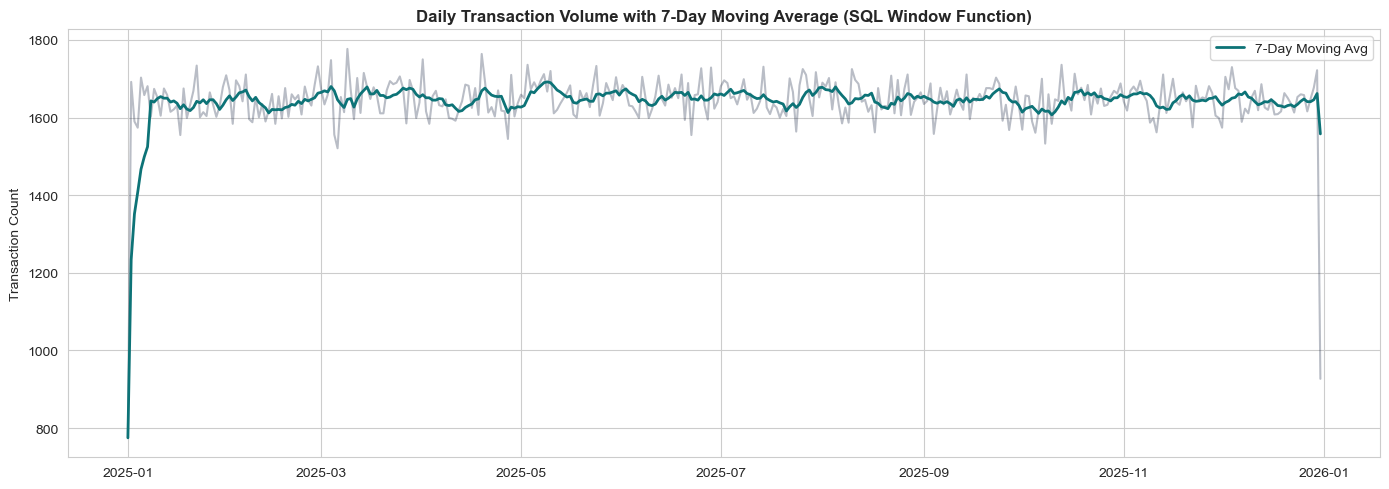

In [12]:
q10 = query("""
SELECT 
    txn_date,
    daily_txn_count,
    ROUND(AVG(daily_txn_count) OVER (
        ORDER BY txn_date 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 0) AS moving_avg_7d,
    daily_volume,
    ROUND(AVG(daily_volume) OVER (
        ORDER BY txn_date 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS moving_avg_volume_7d
FROM (
    SELECT 
        DATE(timestamp) AS txn_date,
        COUNT(*) AS daily_txn_count,
        SUM(amount_ngn) AS daily_volume
    FROM transactions
    GROUP BY DATE(timestamp)
) daily
ORDER BY txn_date
""")

# Plot it
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pd.to_datetime(q10['txn_date']), q10['daily_txn_count'], alpha=0.3, color=COLORS[0])
ax.plot(pd.to_datetime(q10['txn_date']), q10['moving_avg_7d'], color=COLORS[1], linewidth=2, label='7-Day Moving Avg')
ax.set_title('Daily Transaction Volume with 7-Day Moving Average (SQL Window Function)', fontweight='bold')
ax.set_ylabel('Transaction Count')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/sql_moving_avg.png', dpi=150, bbox_inches='tight')
plt.show()

### Query 11: Merchant Ranking by Volume within Each Category (RANK / DENSE_RANK)

In [14]:
q11 = query("""
WITH merchant_vol AS (
    SELECT 
        t.merchant_id,
        m.category,
        SUM(t.amount_ngn) AS total_volume,
        COUNT(*) AS txn_count
    FROM transactions t
    JOIN merchants m ON t.merchant_id = m.merchant_id
    GROUP BY t.merchant_id, m.category
),
ranked AS (
    SELECT 
        merchant_id,
        category,
        total_volume,
        txn_count,
        RANK() OVER (PARTITION BY category ORDER BY total_volume DESC) AS volume_rank,
        DENSE_RANK() OVER (PARTITION BY category ORDER BY total_volume DESC) AS dr
    FROM merchant_vol
)
SELECT *
FROM ranked
WHERE volume_rank <= 5
ORDER BY category, volume_rank
""")
print("Top 5 Merchants per Category by Volume:")
print(q11.to_string(index=False))

Top 5 Merchants per Category by Volume:
merchant_id          category  total_volume  txn_count  volume_rank  dr
   MRC00831      Online_Bills   18300645.92       1503            1   1
   MRC04912      Online_Bills   17792472.73       1431            2   2
   MRC02724      Online_Bills   15567494.85       1267            3   3
   MRC03641      Online_Bills   14406472.00       1164            4   4
   MRC04182      Online_Bills   13921250.05       1123            5   5
   MRC03366  Online_Ecommerce  648877628.89      17995            1   1
   MRC01111  Online_Ecommerce  111650131.02       3107            2   2
   MRC04621  Online_Ecommerce   81733390.19       2254            3   3
   MRC00930  Online_Ecommerce   74104865.87       2061            4   4
   MRC02482  Online_Ecommerce   57728104.62       1589            5   5
   MRC02876     Online_Gaming    3197795.16       1026            1   1
   MRC02033     Online_Gaming    2080670.29        685            2   2
   MRC01529     Online_G

### Query 12: Merchant Transaction Velocity — Days Since Previous Transaction (LAG)

In [15]:
q12 = query("""
WITH daily_merchant AS (
    SELECT 
        merchant_id,
        DATE(timestamp) AS txn_date,
        COUNT(*) AS daily_txns,
        SUM(amount_ngn) AS daily_volume
    FROM transactions
    GROUP BY merchant_id, DATE(timestamp)
),
with_lag AS (
    SELECT 
        merchant_id,
        txn_date,
        daily_txns,
        daily_volume,
        LAG(txn_date) OVER (PARTITION BY merchant_id ORDER BY txn_date) AS prev_txn_date,
        LAG(daily_volume) OVER (PARTITION BY merchant_id ORDER BY txn_date) AS prev_volume
    FROM daily_merchant
)
SELECT 
    merchant_id,
    txn_date,
    daily_txns,
    ROUND(daily_volume, 2) AS daily_volume,
    DATEDIFF(txn_date, prev_txn_date) AS days_since_last_txn,
    ROUND(daily_volume - prev_volume, 2) AS volume_change
FROM with_lag
WHERE DATEDIFF(txn_date, prev_txn_date) > 7
ORDER BY days_since_last_txn DESC
LIMIT 20
""")
print("Merchants with Longest Gaps Between Transactions (Potential Churn Risk):")
print(q12.to_string(index=False))

Merchants with Longest Gaps Between Transactions (Potential Churn Risk):
merchant_id   txn_date  daily_txns  daily_volume  days_since_last_txn  volume_change
   MRC02705 2025-08-23           1      11241.77                   83        -781.60
   MRC01312 2025-10-25           1        770.56                   83        -856.44
   MRC03154 2025-05-14           1      93174.64                   74       64317.87
   MRC02735 2025-08-31           1      33911.15                   72        8090.89
   MRC03811 2025-06-02           1       4249.83                   71      -40240.83
   MRC03455 2025-04-13           1      13340.88                   68        9825.00
   MRC03926 2025-12-20           1     320558.20                   67      320458.20
   MRC00213 2025-11-16           1     285065.96                   67      -46923.69
   MRC03313 2025-12-13           1     206167.04                   67      -57621.18
   MRC04408 2025-09-14           1      16097.76                   66       1

### Query 13: Revenue Concentration — PERCENT_RANK and CUME_DIST

In [16]:
q13 = query("""
WITH merchant_vol AS (
    SELECT 
        merchant_id,
        SUM(amount_ngn) AS total_volume
    FROM transactions
    GROUP BY merchant_id
)
SELECT 
    merchant_id,
    ROUND(total_volume, 2) AS total_volume,
    ROUND(PERCENT_RANK() OVER (ORDER BY total_volume) * 100, 2) AS percentile_rank,
    ROUND(CUME_DIST() OVER (ORDER BY total_volume) * 100, 2) AS cumulative_dist
FROM merchant_vol
ORDER BY total_volume DESC
LIMIT 20
""")
print("Top 20 Merchants by Volume with Percentile Rank:")
print(q13.to_string(index=False))

Top 20 Merchants by Volume with Percentile Rank:
merchant_id  total_volume  percentile_rank  cumulative_dist
   MRC03366  648877628.89           100.00           100.00
   MRC03875  640918505.63            99.98            99.98
   MRC02209  531717046.28            99.96            99.96
   MRC00725  390429468.19            99.94            99.94
   MRC03114  358351351.56            99.92            99.92
   MRC04917  285220477.74            99.90            99.90
   MRC01023  281946757.40            99.88            99.88
   MRC04272  252176327.64            99.86            99.86
   MRC01872  216869596.89            99.84            99.84
   MRC04575  206582548.08            99.82            99.82
   MRC02924  201200892.16            99.80            99.80
   MRC04839  198604178.41            99.78            99.78
   MRC03664  155579052.89            99.76            99.76
   MRC04570  153204786.45            99.74            99.74
   MRC00303  150682548.30            99.72         

---
## SECTION D: NTILE — Merchant Tiering

This is the exact technique from the Moniepoint interview. NTILE splits merchants into equal-sized buckets.

### Query 14: Merchant Tiering by Volume (NTILE — 3 Tiers: A/B/C)

=== MERCHANT TIERING (3-Tier NTILE) ===
           tier  merchant_count  avg_txn_count  tier_total_volume  avg_ticket  avg_fraud_rate_pct
A - High Volume            1666          214.0       2.347956e+10   105674.56                3.46
 B - Mid Volume            1667           88.0       2.072350e+09    17483.99                3.18
 C - Low Volume            1667           58.0       7.569087e+08     8143.53                3.50


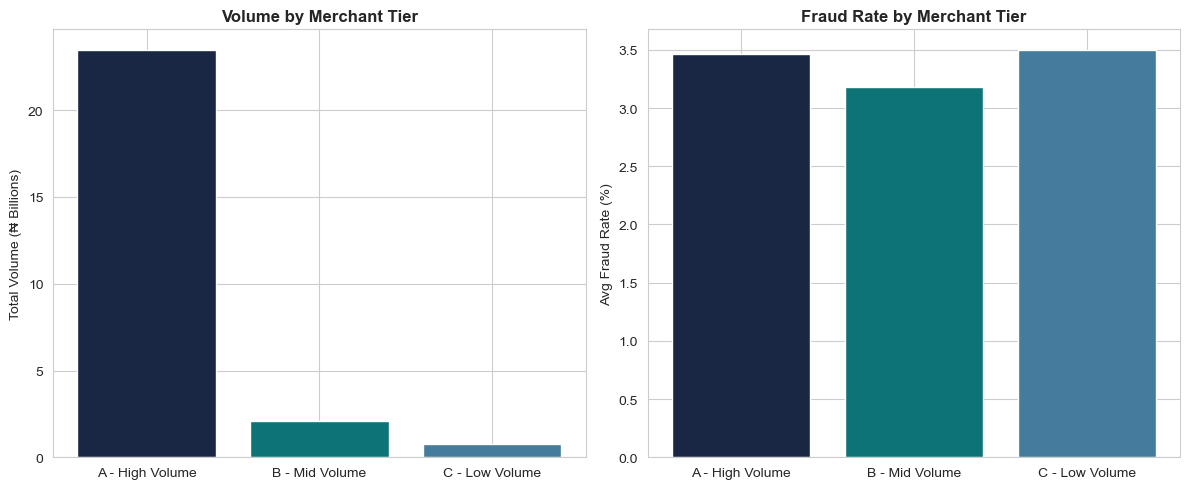

In [17]:
q14 = query("""
WITH merchant_metrics AS (
    SELECT 
        t.merchant_id,
        m.category,
        m.state,
        COUNT(*) AS txn_count,
        SUM(t.amount_ngn) AS total_volume,
        AVG(t.amount_ngn) AS avg_ticket,
        AVG(t.is_fraud) AS fraud_rate
    FROM transactions t
    JOIN merchants m ON t.merchant_id = m.merchant_id
    GROUP BY t.merchant_id, m.category, m.state
),
tiered AS (
    SELECT 
        *,
        NTILE(3) OVER (ORDER BY total_volume ASC) AS volume_tier_num
    FROM merchant_metrics
)
SELECT 
    CASE volume_tier_num
        WHEN 1 THEN 'C - Low Volume'
        WHEN 2 THEN 'B - Mid Volume'
        WHEN 3 THEN 'A - High Volume'
    END AS tier,
    COUNT(*) AS merchant_count,
    ROUND(AVG(txn_count), 0) AS avg_txn_count,
    ROUND(SUM(total_volume), 0) AS tier_total_volume,
    ROUND(AVG(avg_ticket), 2) AS avg_ticket,
    ROUND(AVG(fraud_rate) * 100, 2) AS avg_fraud_rate_pct
FROM tiered
GROUP BY volume_tier_num
ORDER BY volume_tier_num DESC
""")
print("=== MERCHANT TIERING (3-Tier NTILE) ===")
print(q14.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(q14['tier'], q14['tier_total_volume'] / 1e9, color=[COLORS[0], COLORS[1], COLORS[3]])
axes[0].set_ylabel('Total Volume (₦ Billions)')
axes[0].set_title('Volume by Merchant Tier', fontweight='bold')

axes[1].bar(q14['tier'], q14['avg_fraud_rate_pct'], color=[COLORS[0], COLORS[1], COLORS[3]])
axes[1].set_ylabel('Avg Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Merchant Tier', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/ntile_tiering.png', dpi=150, bbox_inches='tight')
plt.show()

### Query 15: 5-Tier Risk Scoring (NTILE — Granular Risk Tiers)

In [18]:
q15 = query("""
WITH merchant_risk AS (
    SELECT 
        t.merchant_id,
        m.category,
        AVG(t.is_fraud) AS fraud_rate,
        SUM(CASE WHEN t.status = 'chargeback' THEN 1 ELSE 0 END) / COUNT(*) AS chargeback_rate,
        SUM(CASE WHEN t.status IN ('declined', 'failed') THEN 1 ELSE 0 END) / COUNT(*) AS decline_rate,
        COUNT(*) AS txn_count
    FROM transactions t
    JOIN merchants m ON t.merchant_id = m.merchant_id
    GROUP BY t.merchant_id, m.category
    HAVING COUNT(*) >= 10
),
risk_tiered AS (
    SELECT 
        *,
        NTILE(5) OVER (ORDER BY fraud_rate ASC) AS risk_tier
    FROM merchant_risk
)
SELECT 
    CASE risk_tier
        WHEN 1 THEN 'Tier 1 - Lowest Risk'
        WHEN 2 THEN 'Tier 2 - Low Risk'
        WHEN 3 THEN 'Tier 3 - Medium Risk'
        WHEN 4 THEN 'Tier 4 - High Risk'
        WHEN 5 THEN 'Tier 5 - Highest Risk'
    END AS risk_tier_label,
    COUNT(*) AS merchant_count,
    ROUND(AVG(fraud_rate) * 100, 3) AS avg_fraud_rate_pct,
    ROUND(AVG(chargeback_rate) * 100, 3) AS avg_chargeback_pct,
    ROUND(AVG(decline_rate) * 100, 2) AS avg_decline_pct,
    ROUND(AVG(txn_count), 0) AS avg_txn_count
FROM risk_tiered
GROUP BY risk_tier
ORDER BY risk_tier
""")
print("=== 5-TIER MERCHANT RISK SCORING (NTILE) ===")
print(q15.to_string(index=False))

=== 5-TIER MERCHANT RISK SCORING (NTILE) ===
      risk_tier_label  merchant_count  avg_fraud_rate_pct  avg_chargeback_pct  avg_decline_pct  avg_txn_count
 Tier 1 - Lowest Risk            1000               0.077               0.025             2.04          108.0
    Tier 2 - Low Risk            1000               1.631               0.553             1.96          126.0
 Tier 3 - Medium Risk            1000               2.765               0.990             1.99          131.0
   Tier 4 - High Risk            1000               4.472               1.588             1.87          130.0
Tier 5 - Highest Risk            1000               7.962               2.724             1.78          104.0


### Query 16: Individual Merchant Tier Assignment (Exportable)

In [19]:
q16 = query("""
WITH merchant_scores AS (
    SELECT 
        t.merchant_id,
        m.category,
        m.state,
        COUNT(*) AS txn_count,
        SUM(t.amount_ngn) AS total_volume,
        ROUND(AVG(t.amount_ngn), 2) AS avg_ticket,
        ROUND(AVG(t.is_fraud) * 100, 2) AS fraud_rate_pct
    FROM transactions t
    JOIN merchants m ON t.merchant_id = m.merchant_id
    GROUP BY t.merchant_id, m.category, m.state
)
SELECT 
    merchant_id,
    category,
    state,
    txn_count,
    ROUND(total_volume, 2) AS total_volume,
    avg_ticket,
    fraud_rate_pct,
    NTILE(3) OVER (ORDER BY total_volume ASC) AS volume_tier,
    NTILE(5) OVER (ORDER BY fraud_rate_pct ASC) AS risk_tier
FROM merchant_scores
ORDER BY fraud_rate_pct DESC
LIMIT 30
""")
print("Top 30 Merchants by Fraud Rate with Tier Assignments:")
print(q16.to_string(index=False))

Top 30 Merchants by Fraud Rate with Tier Assignments:
merchant_id          category   state  txn_count  total_volume  avg_ticket  fraud_rate_pct  volume_tier  risk_tier
   MRC01847  Transfer_Payroll   Abuja         51    9343631.21   183208.46           19.61            3          5
   MRC00241       POS_Grocery    Kano         58     474045.92     8173.21           18.97            1          5
   MRC01395        POS_Retail     Edo         69     727205.65    10539.21           18.84            2          5
   MRC04247      Transfer_P2P   Lagos         48     944846.95    19684.31           18.75            2          5
   MRC01076        POS_Retail     Oyo         54     577454.19    10693.60           18.52            1          5
   MRC02076 Transfer_Business    Abia         44   11192029.34   254364.30           18.18            3          5
   MRC04732          POS_Fuel  Rivers         45     564378.60    12541.75           17.78            1          5
   MRC00022       POS_Groc

---
## SECTION E: Anomaly Detection & Advanced Patterns

### Query 17: Anomalous Transactions — Amount > 3 Standard Deviations from Merchant Average

In [20]:
q17 = query("""
WITH merchant_stats AS (
    SELECT 
        merchant_id,
        AVG(amount_ngn) AS avg_amount,
        STDDEV(amount_ngn) AS std_amount
    FROM transactions
    GROUP BY merchant_id
    HAVING COUNT(*) >= 10
)
SELECT 
    t.transaction_id,
    t.merchant_id,
    t.amount_ngn,
    ROUND(ms.avg_amount, 2) AS merchant_avg,
    ROUND(ms.std_amount, 2) AS merchant_std,
    ROUND((t.amount_ngn - ms.avg_amount) / ms.std_amount, 2) AS z_score,
    t.is_fraud,
    t.status
FROM transactions t
JOIN merchant_stats ms ON t.merchant_id = ms.merchant_id
WHERE (t.amount_ngn - ms.avg_amount) / ms.std_amount > 3
ORDER BY z_score DESC
LIMIT 20
""")
print("Top 20 Anomalous Transactions (Z-Score > 3):")
print(q17.to_string(index=False))

anomaly_fraud_rate = query("""
WITH merchant_stats AS (
    SELECT merchant_id, AVG(amount_ngn) AS avg_amount, STDDEV(amount_ngn) AS std_amount
    FROM transactions GROUP BY merchant_id HAVING COUNT(*) >= 10
)
SELECT 
    CASE WHEN (t.amount_ngn - ms.avg_amount) / ms.std_amount > 3 THEN 'Anomalous' ELSE 'Normal' END AS txn_type,
    COUNT(*) AS txn_count,
    ROUND(AVG(t.is_fraud) * 100, 2) AS fraud_rate_pct
FROM transactions t
JOIN merchant_stats ms ON t.merchant_id = ms.merchant_id
GROUP BY txn_type
""")
print("\nFraud Rate: Normal vs Anomalous Transactions:")
print(anomaly_fraud_rate.to_string(index=False))

Top 20 Anomalous Transactions (Z-Score > 3):
transaction_id merchant_id  amount_ngn  merchant_avg  merchant_std  z_score  is_fraud     status
   TXN00399172    MRC04818    85140.20      20839.73      13841.39     4.65         0  completed
   TXN00340621    MRC02969    40119.44       9288.64       6824.38     4.52         0  completed
   TXN00195329    MRC01664    40211.64      10387.43       6634.46     4.50         0  completed
   TXN00395169    MRC03999   518736.28     154431.25      81594.61     4.46         1 chargeback
   TXN00522752    MRC03875   528425.86     179932.20      80245.29     4.34         0  completed
   TXN00189080    MRC03366   137000.31      36058.77      23253.12     4.34         0  completed
   TXN00505090    MRC00244   887999.80     263024.29     144310.97     4.33         0  completed
   TXN00450792    MRC02384    45602.30      12724.82       7696.83     4.27         0  completed
   TXN00107579    MRC04138    39744.24      10959.19       6793.18     4.24       

### Query 18: Peak Fraud Hours — Hourly Pattern Analysis

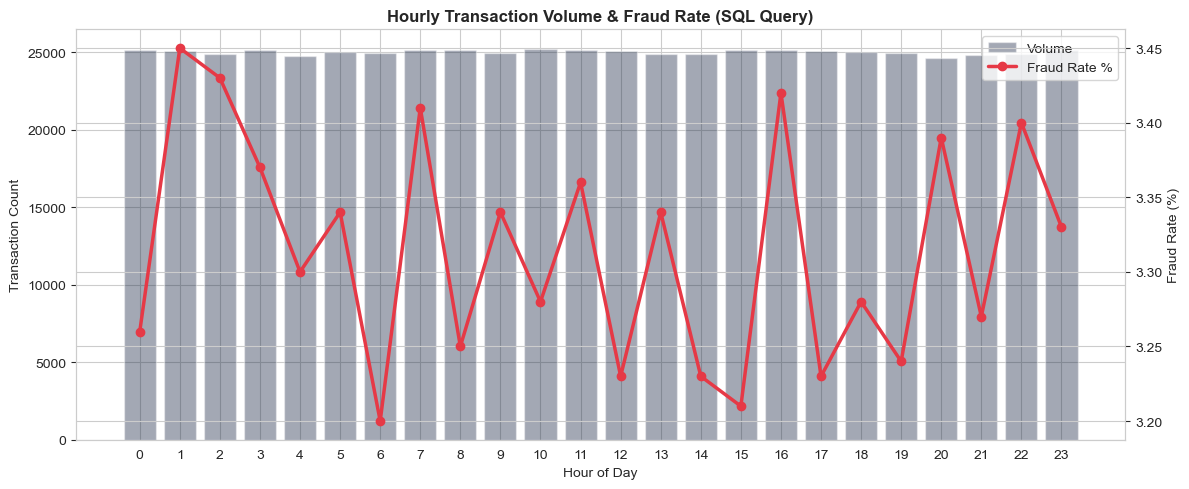

In [21]:
q18 = query("""
SELECT 
    HOUR(timestamp) AS txn_hour,
    COUNT(*) AS txn_count,
    SUM(is_fraud) AS fraud_count,
    ROUND(AVG(is_fraud) * 100, 2) AS fraud_rate_pct,
    ROUND(AVG(amount_ngn), 2) AS avg_amount,
    ROUND(AVG(CASE WHEN is_fraud = 1 THEN amount_ngn END), 2) AS avg_fraud_amount
FROM transactions
GROUP BY HOUR(timestamp)
ORDER BY txn_hour
""")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(q18['txn_hour'], q18['txn_count'], color=COLORS[0], alpha=0.4, label='Volume')
ax2.plot(q18['txn_hour'], q18['fraud_rate_pct'], color=COLORS[2], linewidth=2.5, marker='o', label='Fraud Rate %')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Transaction Count')
ax2.set_ylabel('Fraud Rate (%)')
ax1.set_title('Hourly Transaction Volume & Fraud Rate (SQL Query)', fontweight='bold')
ax1.set_xticks(range(24))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('../reports/sql_hourly_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

### Query 19: Day-of-Week Fraud Patterns

In [22]:
q19 = query("""
SELECT 
    DAYNAME(timestamp) AS day_of_week,
    DAYOFWEEK(timestamp) AS dow_num,
    COUNT(*) AS txn_count,
    SUM(is_fraud) AS fraud_count,
    ROUND(AVG(is_fraud) * 100, 2) AS fraud_rate_pct,
    ROUND(SUM(amount_ngn), 0) AS total_volume
FROM transactions
GROUP BY DAYNAME(timestamp), DAYOFWEEK(timestamp)
ORDER BY dow_num
""")
print(q19.to_string(index=False))

day_of_week  dow_num  txn_count  fraud_count  fraud_rate_pct  total_volume
     Sunday        1      85502       2906.0            3.40  3732177488.0
     Monday        2      85784       2805.0            3.27  3758163462.0
    Tuesday        3      86178       2795.0            3.24  3782113251.0
  Wednesday        4      85544       2877.0            3.36  3749043420.0
   Thursday        5      85587       2785.0            3.25  3759676453.0
     Friday        6      85612       2827.0            3.30  3768513037.0
   Saturday        7      85793       2896.0            3.38  3759129259.0


### Query 20: Merchant Chargeback Concentration — Who Drives the Most Chargebacks?

In [23]:
q20 = query("""
WITH chargeback_merchants AS (
    SELECT 
        t.merchant_id,
        m.category,
        m.state,
        COUNT(*) AS total_txns,
        SUM(CASE WHEN t.status = 'chargeback' THEN 1 ELSE 0 END) AS chargeback_count,
        SUM(CASE WHEN t.status = 'chargeback' THEN t.amount_ngn ELSE 0 END) AS chargeback_volume
    FROM transactions t
    JOIN merchants m ON t.merchant_id = m.merchant_id
    GROUP BY t.merchant_id, m.category, m.state
    HAVING SUM(CASE WHEN t.status = 'chargeback' THEN 1 ELSE 0 END) > 0
)
SELECT 
    merchant_id,
    category,
    state,
    total_txns,
    chargeback_count,
    ROUND(chargeback_count / total_txns * 100, 2) AS chargeback_rate_pct,
    ROUND(chargeback_volume, 2) AS chargeback_volume,
    ROUND(SUM(chargeback_volume) OVER (ORDER BY chargeback_volume DESC) / 
          SUM(chargeback_volume) OVER () * 100, 2) AS cumulative_chargeback_pct
FROM chargeback_merchants
ORDER BY chargeback_volume DESC
LIMIT 20
""")
print("Top 20 Merchants by Chargeback Volume (with Cumulative %):")
print(q20.to_string(index=False))

Top 20 Merchants by Chargeback Volume (with Cumulative %):
merchant_id          category   state  total_txns  chargeback_count  chargeback_rate_pct  chargeback_volume  cumulative_chargeback_pct
   MRC03875  Transfer_Payroll   Abuja        3562              55.0                 1.54         9531919.58                       3.12
   MRC03114 Transfer_Business  Rivers        1406              31.0                 2.20         8268859.81                       5.82
   MRC02209     Online_Travel   Benue        3548              40.0                 1.13         5999803.91                       7.78
   MRC00725  Transfer_Payroll  Rivers        2135              20.0                 0.94         4273259.49                       9.18
   MRC02924 Transfer_Business     Oyo         752              12.0                 1.60         3842191.72                      10.43
   MRC00303 Transfer_Business   Lagos         588              11.0                 1.87         3636487.38                      11

---
## SECTION F: Advanced Multi-Step Queries

### Query 21: New vs Returning Customer Fraud Rates by Month

In [24]:
q21 = query("""
WITH customer_first AS (
    SELECT customer_id, MIN(DATE(timestamp)) AS first_txn_date
    FROM transactions GROUP BY customer_id
)
SELECT 
    DATE_FORMAT(t.timestamp, '%Y-%m') AS month,
    CASE WHEN DATE(t.timestamp) = cf.first_txn_date THEN 'New' ELSE 'Returning' END AS customer_type,
    COUNT(*) AS txn_count,
    ROUND(AVG(t.is_fraud) * 100, 2) AS fraud_rate_pct,
    ROUND(AVG(t.amount_ngn), 2) AS avg_amount
FROM transactions t
JOIN customer_first cf ON t.customer_id = cf.customer_id
GROUP BY DATE_FORMAT(t.timestamp, '%Y-%m'), customer_type
ORDER BY month, customer_type
""")
print(q21.head(12).to_string(index=False))

  month customer_type  txn_count  fraud_rate_pct  avg_amount
2025-01           New      44456            3.36    44081.62
2025-01     Returning       5552            3.21    43334.13
2025-02           New      32146            3.51    43556.89
2025-02     Returning      13843            3.41    43940.58
2025-03           New      28006            3.37    43801.98
2025-03     Returning      23322            3.24    44017.74
2025-04           New      20899            3.31    42979.33
2025-04     Returning      28306            3.25    44343.62
2025-05           New      17167            3.36    42819.39
2025-05     Returning      34407            3.32    43881.41
2025-06           New      12615            3.12    42702.87
2025-06     Returning      36906            3.36    43427.04


### Query 22: Channel Migration — Do Merchants Shift Channels Over Time?

In [25]:
q22 = query("""
WITH merchant_channel_h1 AS (
    SELECT merchant_id, channel, COUNT(*) AS cnt
    FROM transactions
    WHERE timestamp < '2025-07-01' AND channel IS NOT NULL
    GROUP BY merchant_id, channel
),
merchant_channel_h2 AS (
    SELECT merchant_id, channel, COUNT(*) AS cnt
    FROM transactions
    WHERE timestamp >= '2025-07-01' AND channel IS NOT NULL
    GROUP BY merchant_id, channel
),
top_channel_h1 AS (
    SELECT merchant_id, channel AS primary_channel_h1
    FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY merchant_id ORDER BY cnt DESC) AS rn
        FROM merchant_channel_h1
    ) ranked WHERE rn = 1
),
top_channel_h2 AS (
    SELECT merchant_id, channel AS primary_channel_h2
    FROM (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY merchant_id ORDER BY cnt DESC) AS rn
        FROM merchant_channel_h2
    ) ranked WHERE rn = 1
)
SELECT 
    h1.primary_channel_h1,
    h2.primary_channel_h2,
    COUNT(*) AS merchant_count,
    CASE WHEN h1.primary_channel_h1 = h2.primary_channel_h2 THEN 'Retained' ELSE 'Migrated' END AS status
FROM top_channel_h1 h1
JOIN top_channel_h2 h2 ON h1.merchant_id = h2.merchant_id
GROUP BY h1.primary_channel_h1, h2.primary_channel_h2
ORDER BY merchant_count DESC
LIMIT 15
""")
print("Channel Migration H1 vs H2 2025:")
print(q22.to_string(index=False))

Channel Migration H1 vs H2 2025:
primary_channel_h1 primary_channel_h2  merchant_count   status
      POS_Terminal       POS_Terminal            2679 Retained
     Bank_Transfer      Bank_Transfer             680 Retained
       Web_Gateway        Web_Gateway             524 Retained
        Mobile_App        Web_Gateway             286 Migrated
       Web_Gateway         Mobile_App             277 Migrated
        Mobile_App         Mobile_App             211 Retained
        Mobile_App      Bank_Transfer             127 Migrated
     Bank_Transfer         Mobile_App             116 Migrated
        Tap_to_Pay       POS_Terminal              46 Migrated
      POS_Terminal         Tap_to_Pay              38 Migrated
        Mobile_App               USSD               4 Migrated
           QR_Code       POS_Terminal               3 Migrated
      POS_Terminal            QR_Code               3 Migrated
        Tap_to_Pay         Tap_to_Pay               2 Retained
     Bank_Transfer    

### Query 23: Revenue at Risk — High-Risk Merchants Total Exposure

In [26]:
q23 = query("""
WITH merchant_risk AS (
    SELECT 
        t.merchant_id,
        m.category,
        COUNT(*) AS txn_count,
        SUM(t.amount_ngn) AS total_volume,
        AVG(t.is_fraud) AS fraud_rate,
        NTILE(5) OVER (ORDER BY AVG(t.is_fraud) ASC) AS risk_tier
    FROM transactions t
    JOIN merchants m ON t.merchant_id = m.merchant_id
    GROUP BY t.merchant_id, m.category
    HAVING COUNT(*) >= 10
)
SELECT 
    CASE risk_tier
        WHEN 5 THEN 'Tier 5 - Highest Risk'
        WHEN 4 THEN 'Tier 4 - High Risk'
        ELSE 'Tiers 1-3 - Lower Risk'
    END AS risk_group,
    COUNT(*) AS merchant_count,
    ROUND(SUM(total_volume), 0) AS total_volume_at_risk,
    ROUND(SUM(total_volume) / (SELECT SUM(amount_ngn) FROM transactions) * 100, 2) AS pct_of_total_volume,
    ROUND(AVG(fraud_rate) * 100, 2) AS avg_fraud_rate_pct
FROM merchant_risk
GROUP BY risk_group
ORDER BY avg_fraud_rate_pct DESC
""")
print("=== REVENUE AT RISK SUMMARY ===")
print(q23.to_string(index=False))

=== REVENUE AT RISK SUMMARY ===
            risk_group  merchant_count  total_volume_at_risk  pct_of_total_volume  avg_fraud_rate_pct
 Tier 5 - Highest Risk            1000          4.113657e+09                15.64                7.96
    Tier 4 - High Risk            1000          6.237112e+09                23.71                4.47
Tiers 1-3 - Lower Risk            3000          1.595805e+10                60.66                1.49


---
## Summary: SQL Skills Demonstrated

| Technique | Queries | Interview Relevance |
|-----------|---------|--------------------|
| GROUP BY + Aggregation | Q1-Q5 | Every SQL interview |
| CTEs (WITH clause) | Q6-Q8 | Standard at Moniepoint, Paystack |
| Window Functions (SUM/AVG OVER) | Q9-Q10 | Senior analyst interviews |
| RANK / DENSE_RANK | Q11 | Common ranking questions |
| LAG / LEAD | Q12 | Time-gap analysis |
| PERCENT_RANK / CUME_DIST | Q13 | Revenue concentration |
| NTILE (3-tier, 5-tier) | Q14-Q16 | Exact Moniepoint interview pattern |
| Z-Score anomaly detection | Q17 | Advanced analytics |
| Time extraction (HOUR, DAYNAME) | Q18-Q19 | Pattern analysis |
| Cumulative window functions | Q20 | Chargeback concentration |
| Multi-CTE + CASE WHEN | Q21-Q23 | Complex business logic |

**Total: 23 queries covering every major SQL concept tested in fintech data analyst interviews.**

---

**Next:** `03_feature_engineering.ipynb` — Build merchant-level feature table for the ML risk model.